In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import numpy as np
from numpy.random import default_rng
from scipy.ndimage import convolve, gaussian_filter,maximum_filter,grey_dilation
%matplotlib inline
rng = default_rng()

## Fractions Skill Score (FSS)
### Sensitivity to multi-scale structure

Evaluating forecasts that have a realistic degree of spatial and temporal variability has been a significant challenge for several decades (e.g., Anthes 1983; Davis and Carr 2000; Ebert 2008; Gilleland et al. 2009; Dorninger et al. 2018). The “double penalty” issue arises with even slight imperfections in forecasts that contain realistic variability, where measures related to the difference between observed and predicted values will penalize the forecast for predicting an event where it did not occur and again for not predicting an event where it did occur. Numerous approaches for evaluating realistic forecasts have been developed, which can generally be categorized as multiscale analysis methods (e.g., Casati et al. 2004, Harris et al. 2001), feature-based (e.g., Ebert and McBride 2000; Davis et al. 2006), field deformation (e.g., Hoffman et al. 1995; Marzban et al. 2009), and neighborhood approaches (Ebert 2008; Ebert 2009) Of these, the Fractions Skill Score (Roberts and Lean 2008) has emerged as one of the most widely-used approaches for measuring the performance of realistic spatial forecast fields. (Google Scholar shows that it has been cited in 1500+ papers)

The "neighborhood" approach is designed to give credit to imperfect but “useful” forecasts, for instance forecasts that contain realistic variability along with some displacement in time or space. Neighborhood methods measure the accuracy/skill of the forecasts within "windows" in space and/or time. Roberts and Lean (2008) expressed the motivation for this approach in terms of determining the scale(s) at which forecasts become useful: “Techniques are required that can evaluate scales at which forecasts become sufficiently skillful and identify the scales over which increased resolution is beneficial (if any).” 

### Issues with FSS

In previous work, several authors have raised issues with this score. While technically a skill score, it does not behave like a typical measure of skill. Mittermaier (2021) discussed issues with calculating summary FSS values over a large set of cases, especially those containing correct forecasts of zero precipitation over the domain. FSS is highly sensitive to frequency bias. While a perfect forecast will have FSS=1, Roberts and Lean (2008) show that the "asymptotic" value of FSS will be equal to 1 only if the forecasts are unbiased. Skok and Roberts (2018) discuss the FSS's significant sensitivity to bias, and mention that "in cases with a large bias, the FSS will never reach the value of 0.5" which many authors choose as the threshold for determining the scale of "useful" forecasts. Skok (2015), Mittermaier (2021), and Antonio and Aitchison (2025) each discuss issues with the assumption that the FSS=0.5 threshold indicates that the forecasts become "skillful" or "useful" and the dependence of this on the observed event frequency. 

It is also problematic to consider values of FSS=0 as indicating "no skill". For instance, Skok and Roberts (2016) showed that FSS increases monotonically with increasing neighborhood size for random forecasts, at a rate that varies with event frequency. Antonio and Aitchison (2025) showed that at the grid scale, FSS for a random forecast is greater than zero and equal to the observed event frequency. They also derived an expression for the expected value of FSS for an unbiased random forecast (with no spatial autocorrelation) for any neighborhood scale, which increases with increasing neighborhood width. They recommended providing this "random" value of FSS as a baseline in order to properly measure "skill" using FSS. However, they also showed examples where seemingly skillful forecasts that had correlation coefficients exceeding 0.5 also showed FSS values that failed to exceed this "random" baseline value, indicating a lack of skill by this criteria.  

Measures of skill are typically derived by normalizing a measure of accuracy (or error) in such a way that the numerical value of the measure varies from zero to one between forecasts considered to have “no skill” and perfect forecasts. The “no skill” baseline is defined as a forecast system with accuracy equal to a standard or “reference” approach, such as random chance, climatology, persistence (AMS Glossary), or a constant forecast (such as “all no” or “all yes”). The choice of reference forecast is an important issue in understanding a quantitative measure of skill, just as the reference point on an interval temperature scale allows one to interpret the numerical values of temperature measurements. For example, the traditional form of the Brier skill score (BSS) was derived using an unbiased single-valued (constant) reference forecast (Murphy 1974) equal to the observed event frequency (base rate) from the verification sample. There are several studies (e.g., Murphy 1988; Mason 2004; Hamill and Juras 2006) that have noted issues with using single-valued reference forecasts to quantify skill, particularly when the verification dataset is aggregated over pooled subsets that have different base rates or forecast variances. Rather than a constant reference forecast, many other traditional skill scores from the 2x2 contingency table were defined using “random chance” as the reference forecast (e.g., Gilbert 1884; Peirce 1884; Doolittle 1885; Heidke 1925; Doswell et al. 1990; Schaefer 1990). 

In the case of FSS, Roberts and Lean (2008) defined the score by normalizing the mean squared error (MSE) using a reference forecast that has the “largest possible MSE than can be obtained from the forecast and observed fractions” (Roberts and Lean 2008) for each neighborhood window. Mittermaier (2021) explained that this reference forecast was not always possible to achieve in reality, especially for relatively high observed event frequencies. Unlike other skill scores, the FSS reference forecast is determined from the forecast that is being evaluated, therefore each forecast may have a different baseline. As a result, practitioners may be able to take advantage of FSS senstivities in the design of their forecast systems to produce higher scores, which may not actually correspond to higher-quality forecasts. Unfortunately, the information required to determine the value of the score represented by the baseline or reference forecast is not always provided when measures of skill are reported. As we will find, this is especially problematic for FSS since the behavior of the baseline does not remain consistent as the neighborhood window size increases, or between forecasts with different degrees of spatial structure. Without a clear and consistent baseline, any meaningful comparison of "skill" (FSS in this case) across multiple forecast systems becomes nearly impossible.

### FSS decomposition

Roberts and Lean (2008) defined FSS by normalizing the mean squared error (also called the Fractions Brier Score or FBS, Roberts and Lean 2008) using a reference forecast that has the “largest possible MSE than can be obtained from the forecast and observed fractions” (Roberts and Lean 2008) for each neighborhood window. To calculate FSS, observed and forecasted fields are thresholded to produce binary values. The neighborhood approach proceeds by generating forecasted and observed “fractions” through the calculation of the fraction of grid cells having a value of 1 within a window or neighborhood, or a simple average of the binary values within a “n x n” square window. (other window shapes can be used, such as circular) The normalized mean squared error of these fractions is typically calculated for monotonically increasing neighborhood/window sizes, potentially until the averaging reaches the size of the full spatial domain of the forecast system. 

Since these fractions are similar to probabilities, we will use the same notation that Murphy (1988) used to analyze MSE-based measures for probability forecasts. The fraction of forecast values for the n-th neighborhood window at the i-th location/time will be denoted as $f_i[n]$, while the fraction of observed values for the n-th neighborhood window at the i-th location/time will be denoted as $x_i[n]$. To simplify the notation, we will drop the $[n]$ scripting, recognizing that each of these terms are calculated for each neighborhood averaging window size. FSS for the n-th neighborhood window is computed over all locations/times:

\begin{equation}
FSS=1-\frac{\frac{1}{N}\sum(f_i-x_i)^2}{\frac{1}{N}\sum(f_i)^2+\frac{1}{N}\sum(x_i)^2}
=1-\frac{MSE}{MSE_{ref}}
\end{equation}

\begin{equation}
MSE=\frac{1}{N}\sum(f_i-x_i)^2=\frac{1}{N}\sum(f_i)^2+\frac{1}{N}\sum(x_i)^2-\frac{2}{N}\sum(f_i x_i)
\end{equation}

\begin{equation}
MSE_{ref}=\frac{1}{N}\sum(f_i)^2+\frac{1}{N}\sum(x_i)^2
\end{equation}

By completing the square in the numerator, mean squared error can be expressed in terms of the second moments along with the product moment of the forecasts and observations. The reference MSE was defined as the forecast with the “largest possible MSE”, by setting the product moment of the forecasts and observations to zero, at the grid scale this is effectively the same as a forecast with zero overlap with the observations. To help in understanding the behavior of FSS, we will use a standard decomposition of MSE (Murphy 1988) and substitute the definitions of the sample means, variances, and covariance/correlation of the forecast and observed fractions:

$\bar x=\frac{1}{N}\sum x_i$

$\bar f=\frac{1}{N}\sum f_i$

$s_x^2=\frac{1}{N}\sum(x_i)^2-(\frac{1}{N}\sum x_i)^2$

$s_f^2=\frac{1}{N}\sum(f_i)^2-(\frac{1}{N}\sum f_i)^2$

$s_{fx}=\frac{1}{N}\sum(f_i x_i)-(\frac{1}{N}\sum f_i)(\frac{1}{N}\sum x_i)$

$r=\frac{s_{fx}}{s_f s_x}$

$MSE=s_f^2+s_x^2+{\bar f}^2+{\bar x}^2-2s_{fx}-2\bar f \bar x=(s_f-s_x)^2 + (\bar f - \bar x)^2 + 2s_fs_x(1-r)=MSE_{sharp}+MSE_{bias}+MSE_{corr}$

We find MSE expressed in terms of the sum of three error components, the first of which is the squared difference between the forecast and true/observed standard deviations, which we will denote as a general "sharpness" error component $(MSE_{sharp})$. The second term is the squared difference between the mean forecast and mean observed value, which will will call the "bias" component $(MSE_{bias})$. The third term is a weighted difference between "perfect" correlation (=1) and the sample correlation coefficient, which we will denote as the "correlation" error component $(MSE_{corr})$. We will find these error components in various forms as we continue analyzing the behavior of FSS.

In order to simplify the analysis, we manipulate $FSS$ terms to attempt to separate correlation and sharpness and bias error components:
\begin {equation}
FSS=\frac{2(s_{fx}+\bar f \bar x)}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}=\frac{r(2s_f s_x)+ 2\bar f \bar x)}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}
\end {equation}

\begin {equation}
FSS=r \frac{s_f^2+s_x^2}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}\frac{2s_f s_x}{s_f^2+s_x^2} + \frac{{\bar f}^2+{\bar x}^2}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}\frac{2\bar f \bar x}{{\bar f}^2+{\bar x}^2}
\end {equation}

The three components of MSE error can be converted to expressions of "skill", normalizing each term separately (assuming perfect MSE terms = 0):

\begin {equation}
\phi_{sharp}=\frac{2s_f s_x}{s_f^2+s_x^2}=1-\frac{(s_f-s_x)^2}{s_f^2+s_x^2}=1-\frac{MSE_{sharp}}{s_f^2+s_x^2}
\end {equation}

\begin {equation}
\phi_{bias}=\frac{2\bar f \bar x}{{\bar f}^2+{\bar x}^2}=1-\frac{(\bar f - \bar x)^2}{{\bar f}^2+{\bar x}^2}=1-\frac{MSE_{bias}}{{\bar f}^2+{\bar x}^2}
\end {equation}

\begin {equation}
\phi_{corr}=1-\frac{2s_fs_x(1-r)}{2s_fs_x}=1-\frac{MSE_{corr}}{2s_fs_x} = r
\end {equation}

We find that the sharpness skill component term $(\phi_{sharp})$ will be equal to one when the forecast variance is equal to the observed, and will decrease as $MSE_{sharp}$ increases (larger mismatch between forecasts and observations). The bias skill component term $(\phi_{sharp})$ behaves similarly, it is equal to one when the forecast is unbiased and decreases as $MSE_{bias}$ gets larger. The correlation skill component $(\phi_{corr})$ is simply equal to the correlation coefficient, so we will use $r$ to represent this component and simply the notation going forward.

FSS can be expressed in terms of a weighted sum of the components of skill involving correlation, sharpness, and bias, using the following weight term:

\begin {equation}
w=\frac{{\bar f}^2+{\bar x}^2}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}=\frac{{\bar{\mu}}^2}{{\bar{\sigma}}^2+{\bar{\mu}}^2}
\end {equation}

\begin {equation}
FSS=r (1-w) \phi_{sharp} + (w) \phi_{bias}
\end {equation}

We should expect that $(w)$ will have a controlling effect on $FSS$ behavior. $w$ could be considered a "baseline" FSS value, since $FSS\approx w$ for a forecast containing zero correlation with the observations (typically called a "random" forecast) while also assuming the sharpness and bias "skill" terms are nearly equal to one $(\phi_{sharp}\approx \phi_{bias} \approx 1)$. The complement of this term $(1-w)$ determines the weight applied to the product of the correlation coefficient and the sharpness skill terms in the value of FSS, which is the term most directly related to the degree of similarity between the forecasted and observed fields.

The weight term $w$ is the ratio of the sum of the squared means to the sum of the variances and squared means of the forecasted and observed fractions. In contrast to the other components of FSS, $w$ is not directly related to the degree of difference or similarity between the forecasts and observations, but is instead a measure of the combined "uniformity" of the fractions fields. If the fractions fields are nearly constant, perhaps when the neighborhood window approaches the size of the full domain, the variances will be vanishingly small and the fraction fields are considered completely uniform $(w\approx 1)$. On the other hand, minimum uniformity should be expected at the grid scale when the fields are binary, the variances will have their largest values and $w$ will be small. In fact, $w$ is the reciprocal of a measure of heteorgeneity known as "lacunarity" $(\Lambda=1+\frac{\sigma^2}{\mu^2})$ which is used in spatial analysis of texture and fractal dimension (e.g., Plotnick et al. 1996). The neighborhood window approach used in $FSS$ closely follows the "gliding-box" lacunarity analysis method proposed by Allain and Cloitre (1991).

Allain, C. and Cloitre, M., 1991. Characterizing the lacunarity of random and deterministic fractal sets. Physical review A, 44(6), p.3552.

Plotnick, R.E., Gardner, R.H., Hargrove, W.W., Prestegaard, K. and Perlmutter, M., 1996. Lacunarity analysis: a general technique for the analysis of spatial patterns. Physical review E, 53(5), p.5461.

### Real data example

We will use an example case from the 2026 HWT Spring Forecasting Experiment to illustrate various points in this notebook. These fields are in the "hrrr_cref.npz" file for this notebook. The 1630 Day 1 Outlook for this event had a slight risk across the Pacific NW. Observations are obtained from composite reflectivity analysis from MRMS, remapped to the HRRR grid ("cref"). A 22h CREF forecast from the HRRR valid 2200 UTC 28 May 2026 is used ("hrrr"). This field is randomly shuffled (using numpy.random.Generator.permuted) to produce a "blurred" version of that forecast, which will be called the "BlurCast" ("blur"). Binary fields were generated using a 30 dBZ threshold on the MRMS CREF ("obs"), a percentile-based threshold to generate unbiased binary forecast fields from the HRRR ("skill_fcst") and BlurCast ("rand_fcst"). A square domain of 333x333 points centered over eastern Oregon is used, the resulting event frequency (base rate) for this example is $\bar x \approx 0.02$. ). At the original grid scale the resulting POD for the HRRR is $POD = 0.06$, and for the BlurCast $POD \approx 0.02$, which is also the expected value $(POD=\bar x)$ for an unbiased random forecast.

The following code blocks will read and plot the example data for the notebook.

In [2]:
data=np.load("hrrr_cref.npz")
cref=data['cref']
hrrr=data['hrrr']
rng=np.random.default_rng(987654321)
blur=rng.permuted(hrrr)
obs=(cref>=30.).astype(float)
base_rate=np.round(np.mean(obs),2)
skill_fcst=(hrrr>=np.quantile(np.nan_to_num(hrrr),1.-np.mean(obs))).astype(float)
rand_fcst=(blur>=np.quantile(np.nan_to_num(blur),1.-np.mean(obs))).astype(float)

lats2d=data['lats2d']
lons2d=data['lons2d']


# calculate CSI and POD from binary field
skill_csi=np.sum(obs*skill_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*skill_fcst))
rand_csi=np.sum(obs*rand_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*rand_fcst))
skill_pod=np.sum(obs*skill_fcst)/np.sum(obs)
rand_pod=np.sum(obs*rand_fcst)/np.sum(obs)


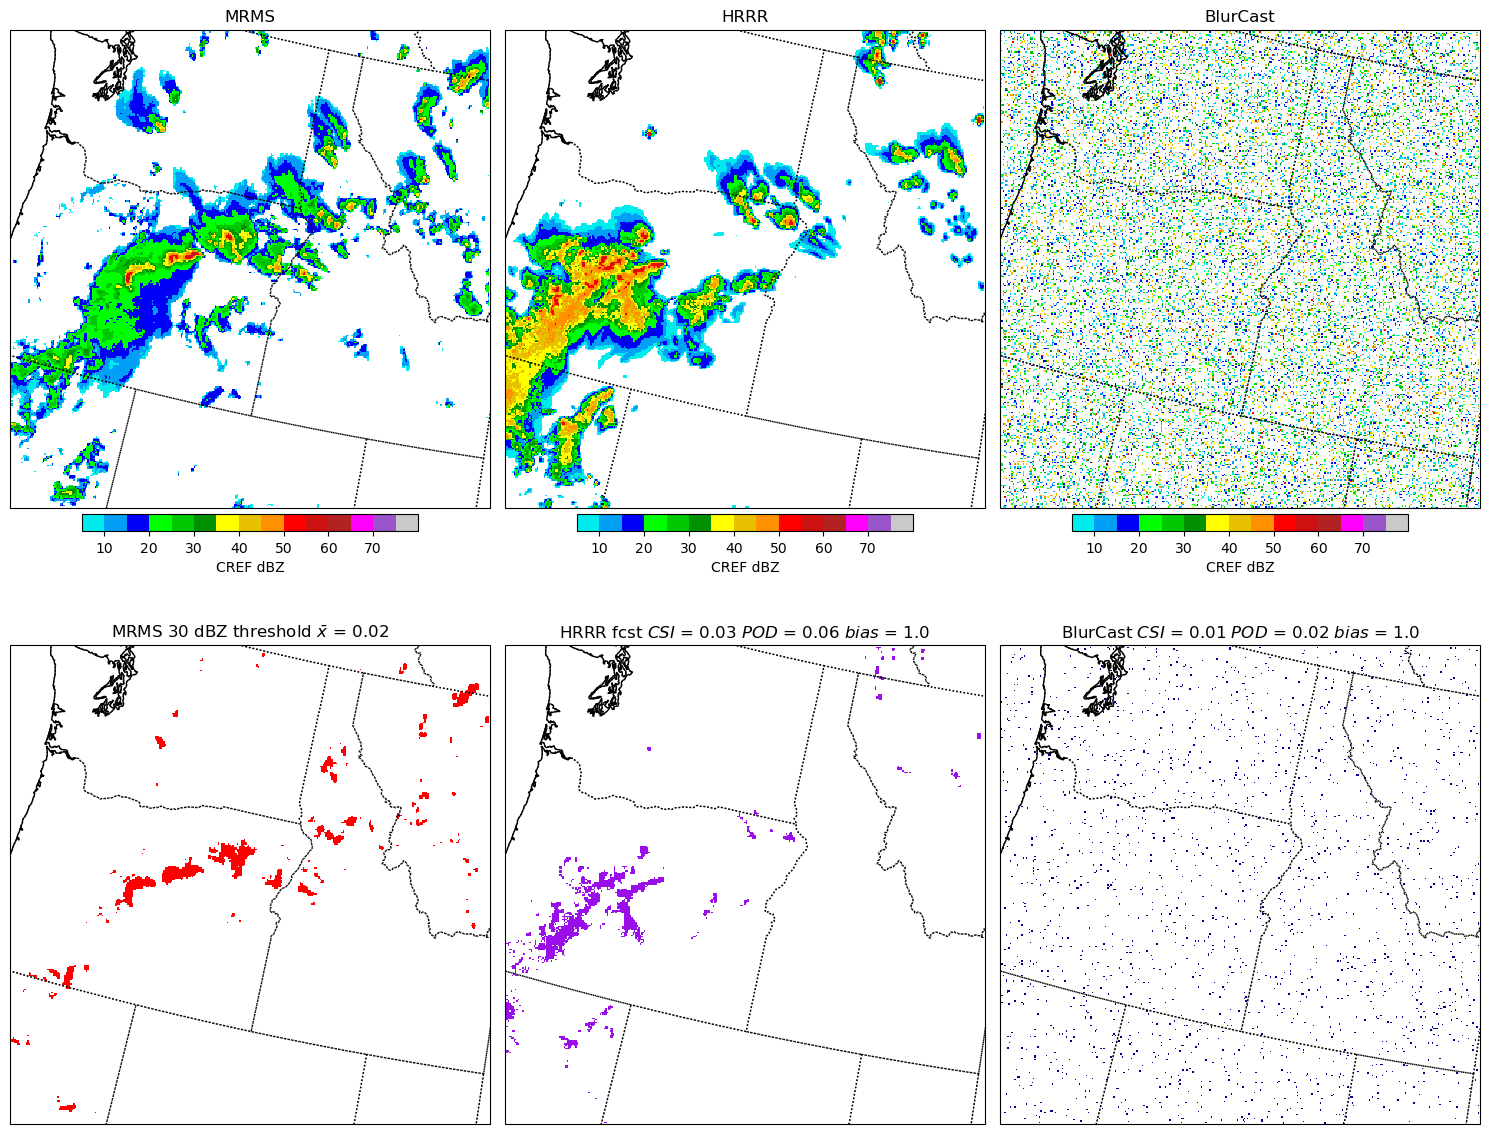

In [3]:
# plot these fields



colorlist=['xkcd:fire engine red','xkcd:violet','xkcd:water blue','xkcd:medium green']
cmap = colors.ListedColormap(['#00ecec','#01a0f6','#0000f6','#00ff00','#00c800','#009000','#ffff00','#e7c000','#ff9000','#ff0000','#cd1010','#b22222','#ff00ff','#9955c9','#c9c9c9'])
mapcrs = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=0.,
                               standard_parallels=(38.5, 38.5))
datacrs = ccrs.PlateCarree()

fig,ax = plt.subplots(2,3,figsize=(15,12),subplot_kw={'projection':mapcrs})
axs=ax.flat

cref_nan=cref
cref_nan[cref_nan<5.]=np.nan
map_extent=[lons2d[0,0]-0.65, lons2d[-1,-1]+0.41,lats2d[0,-1]-0.2, lats2d[-1,0]+0.615 ]

axs[0].add_feature(cfeat.COASTLINE)
axs[0].add_feature(cfeat.STATES, linestyle=':')
axs[0].set_extent(map_extent, ccrs.PlateCarree())
sc=axs[0].pcolormesh(lons2d,lats2d,cref_nan,transform=datacrs,cmap=cmap,vmin=5.,vmax=80.,shading='nearest')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[0])
cbar.set_ticks(np.arange(10,80,10))
cbar.set_label('CREF dBZ')
axs[0].set_title('MRMS')

cref_nan=hrrr
cref_nan[cref_nan<5.]=np.nan

axs[1].add_feature(cfeat.COASTLINE)
axs[1].add_feature(cfeat.STATES, linestyle=':')
axs[1].set_extent(map_extent, ccrs.PlateCarree())
sc=axs[1].pcolormesh(lons2d,lats2d,cref_nan,transform=datacrs,cmap=cmap,vmin=5.,vmax=80.,shading='nearest')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[1])
cbar.set_ticks(np.arange(10,80,10))
cbar.set_label('CREF dBZ')
axs[1].set_title('HRRR')

cref_nan=blur
cref_nan[cref_nan<5.]=np.nan

axs[2].add_feature(cfeat.COASTLINE)
axs[2].add_feature(cfeat.STATES, linestyle=':')
axs[2].set_extent(map_extent, ccrs.PlateCarree())
sc=axs[2].pcolormesh(lons2d,lats2d,cref_nan,transform=datacrs,cmap=cmap,vmin=5.,vmax=80.,shading='nearest')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[2])
cbar.set_ticks(np.arange(10,80,10))
cbar.set_label('CREF dBZ')
axs[2].set_title('BlurCast')

cmap_obs=colors.ListedColormap(['white',colorlist[0]])
axs[3].add_feature(cfeat.COASTLINE)
axs[3].add_feature(cfeat.STATES, linestyle=':')
axs[3].set_extent(map_extent, ccrs.PlateCarree())
sc=axs[3].pcolormesh(lons2d,lats2d,obs,transform=datacrs,cmap=cmap_obs,shading='nearest')
axs[3].set_title(r'MRMS 30 dBZ threshold $\bar x$ = '+f'{base_rate}')

cmap_fcst=colors.ListedColormap(['white',colorlist[1]])
axs[4].add_feature(cfeat.COASTLINE)
axs[4].add_feature(cfeat.STATES, linestyle=':')
axs[4].set_extent(map_extent, ccrs.PlateCarree())
axs[4].set_title(r'HRRR fcst $CSI$ = '+f'{np.round(skill_csi,2)} $POD$ = {np.round(skill_pod,2)} $bias$ = {np.round(np.mean(skill_fcst)/np.mean(obs),1)}')
sc=axs[4].pcolormesh(lons2d,lats2d,skill_fcst,transform=datacrs,cmap=cmap_fcst,shading='nearest')

cmap_rand=colors.ListedColormap(['white','#00008b'])
axs[5].add_feature(cfeat.COASTLINE)
axs[5].add_feature(cfeat.STATES, linestyle=':')
axs[5].set_extent(map_extent, ccrs.PlateCarree())
sc=axs[5].pcolormesh(lons2d,lats2d,rand_fcst,transform=datacrs,cmap=cmap_rand,shading='nearest')
axs[5].set_title(r'BlurCast $CSI$ = '+f'{np.round(rand_csi,2)} $POD$ = {np.round(rand_pod,2)} $bias$ = {np.round(np.mean(rand_fcst)/np.mean(obs),1)}')

plt.tight_layout()

### calculate FSS and other statistics for this example

The code below computes the fractions of the observations, skillful (HRRR) forecast, and random (BlurCast) forecast over a range of neighborhood window widths. The "convolve" function from scipy.ndimage ('reflective' mode as recommended by Antonio and Aitchison 2025) is used to calculate the fractions. A variety of statistics are calculated for each neighborhood scale, including FSS, variances, and correlation coefficient. 

In [4]:
# calculate FSS and various stats across a range of 2-D neighborhood windows
# using 'reflective' convolution from scipy.ndimage

fss_skill=np.zeros(29)
fss_rand=np.zeros_like(fss_skill)
sx_2_n=np.zeros_like(fss_skill)
xbar_n=np.zeros_like(fss_skill)
sf_2_skill=np.zeros_like(fss_skill)
sf_x_skill=np.zeros_like(fss_skill)
sf_2_rand=np.zeros_like(fss_skill)
sf_x_rand=np.zeros_like(fss_skill)
fbar_skill=np.zeros_like(fss_skill)
fbar_rand=np.zeros_like(fss_skill)
win_width=np.zeros_like(fss_skill)
win_size=np.zeros_like(fss_skill)
rfx_skill=np.zeros_like(fss_skill)
rfx_rand=np.zeros_like(fss_skill)

iwins=(np.arange(29)-5)*4+11
iwins[0:5]=np.arange(5)*2+1

for n in np.arange(fss_skill.shape[0]):
    iwin=iwins[n]
    #print(iwin)
    win=iwin*iwin*1.0        # neighborhood window size = number of grid points
    obs_frac=convolve(obs,np.ones((iwin,iwin))/win,mode='reflect')     # use convolution to calculate the fractions
    skill_frac=convolve(skill_fcst,np.ones((iwin,iwin))/win,mode='reflect')
    rand_frac=convolve(rand_fcst,np.ones((iwin,iwin))/win,mode='reflect')
    # compute various stats from the fractions
    win_width[n]=iwin
    win_size[n]=win
    sx_2_n[n]=np.var(obs_frac)
    xbar_n[n]=np.mean(obs_frac)
    sf_2_skill[n]=np.var(skill_frac)
    fbar_skill[n]=np.mean(skill_frac)
    sf_x_skill[n]=np.cov([obs_frac.flatten(),skill_frac.flatten()])[0][1]
    fss_skill[n]=1.-np.mean((skill_frac-obs_frac)**2.)/(np.mean(skill_frac**2.)+np.mean(obs_frac**2.))
    rfx_skill[n]=np.corrcoef([obs_frac.flatten(),skill_frac.flatten()])[0][1]
    sf_2_rand[n]=np.var(rand_frac)
    fbar_rand[n]=np.mean(rand_frac)
    sf_x_rand[n]=np.cov([obs_frac.flatten(),rand_frac.flatten()])[0][1]
    fss_rand[n]=1.-np.mean((rand_frac-obs_frac)**2.)/(np.mean(rand_frac**2.)+np.mean(obs_frac**2.))
    rfx_rand[n]=np.corrcoef([obs_frac.flatten(),rand_frac.flatten()])[0][1]



### plot FSS, normalized sharpness, and correlation vs neighborhood size

The code below generates a plot of FSS versus neighborhood window width (length of the "nxn" square window in units of km, assuming a 3km grid spacing) and compares the skillful (HRRR) forecast to the random (BlurCast) forecast in the left subplot. Dashed black line in left-hand chart represents “uniform FSS” baseline which is commonly-used to determine the useful scales of the forecast, defined by Roberts and Lean (2008) as $FSS_{uniform}=\frac{1+\bar x}{2}$. The correlation coefficients ($r$) for these example forecasts are displayed in the right subplot.

(-0.06, 0.56)

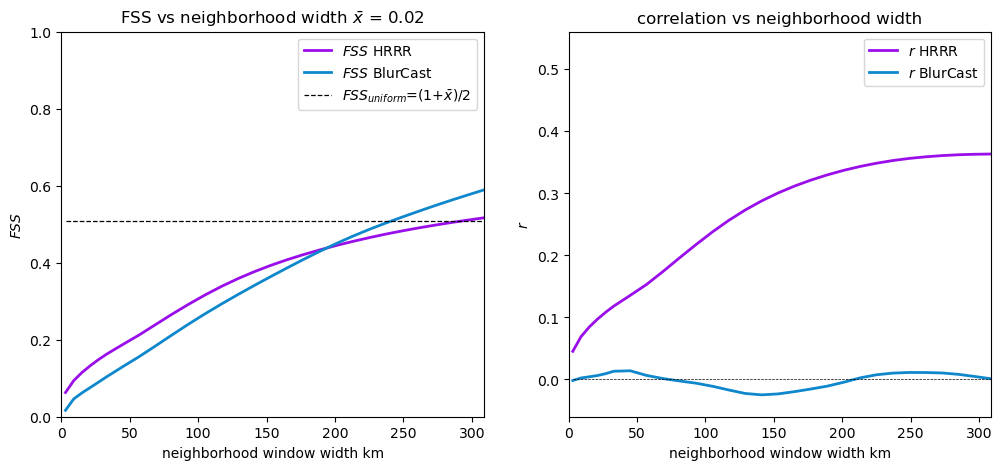

In [5]:
# FSS on the left subplot, correlation on the right subplot

xbar=np.mean(obs)
win_width_km=win_width*3.

fig,ax = plt.subplots(1,2,figsize=(12,5))
axs=ax.flat

axs[0].plot(win_width_km,fss_skill,c=colorlist[1],lw=2.,label=r'$FSS$ HRRR')
axs[0].plot(win_width_km,fss_rand,c=colorlist[2],lw=2.,label=r'$FSS$ BlurCast')
axs[0].plot(win_width_km,np.zeros_like(win_width)+0.5+xbar*0.5,c='k',ls='--',lw=0.9,label=r'$FSS_{uniform}$=(1+$\bar x$)/2')
axs[0].legend()
axs[0].set_xlabel('neighborhood window width km')
axs[0].set_ylabel(r'$FSS$')
axs[0].set_title(r'FSS vs neighborhood width $\bar x$ ='+f' {np.round(xbar,2)}')
axs[0].set_xlim(0.,np.max(win_width_km))
axs[0].set_ylim(0.,1.)


axs[1].plot(win_width_km,rfx_skill,c=colorlist[1],lw=2.,label=r'$r$ HRRR')
axs[1].plot(win_width_km,rfx_rand,c=colorlist[2],lw=2.,label=r'$r$ BlurCast')
axs[1].plot(win_width_km,np.zeros_like(win_width),c='k',ls='--',lw=0.5)
axs[1].legend()
axs[1].set_xlabel('neighborhood window width km')
axs[1].set_ylabel(r'$r$')
axs[1].set_title(r'correlation vs neighborhood width')
axs[1].set_xlim(0.,np.max(win_width*3.))
axs[1].set_ylim(-0.06,0.56)



### FSS behavior

For each of the forecasts in this example, $FSS$ increases monotonically. For the HRRR forecast, $FSS$ starts at the grid scale (window width = 1) with a value of ~0.06 (equal to POD computed from binary forecasts and observations)) and increases with increasing neighborhood window size, eventually exceeding what is typically used as the baseline for determining the scale for useful forecasts (defined as $FSS_{uniform}=\frac{1+\bar x}{2}$ by Roberts and Lean (2008) who described it as "halfway between random forecast skill and perfect skill") for a neighborhood window ~300 km in width. $FSS$ for the BlurCast forecast starts at the grid scale with a value of ~0.02 (equal to POD from random forecast) and exceeds the $FSS_{uniform}$ baseline for neighborhood window widths beyond ~250 km. In fact, $FSS$ from the random forecast exceeds that from the HRRR for neighborhood widths beyond ~200 km.

Antonio and Aitchison (2025) and Skok and Roberts (2016) found similar FSS behavior for random forecasts (increasing with neighborhood scale). Antonio and Aitchison (2025) recommended using $FSS$ from a random unbiased forecast with zero autocorrelation (BlurCast is one realization of such a random/unbiased/zero autocorrelation field) as the "reference" curve when deriving "skill". Using this approach in this example, the skillful/compact forecast would be not be considered skillful for neighborhood scales beyond ~200 km in width. However, the right subplot above shows the correlation coefficient for the HRRR increasing with increasing neighborhood scale before reaching a plateau near $r \approx 0.35$ for windows greater than ~200 km in width. This behavior might be expected from a forecast that is generally "close" to the observations. On the other hand, the random forecast shows nearly zero correlation with the observed fractions across all neighborhood window widths. Since both the skillful (HRRR) and random (BlurCast) forecasts show monotonically increasing FSS scores, it is difficult to find a signal of this "plateau" in performance of the HRRR (or determining the scale where that occurs) by analyzing the FSS values alone. Typical analysis of $FSS$ of the random/patchy forecast might have also identified useful scales from that forecast, but seeing that the correlation coefficient remains near/below zero across all neighborhood sizes clearly indicates that the random forecast would not be useful at any scale in this example.


(0.0, 309.0)

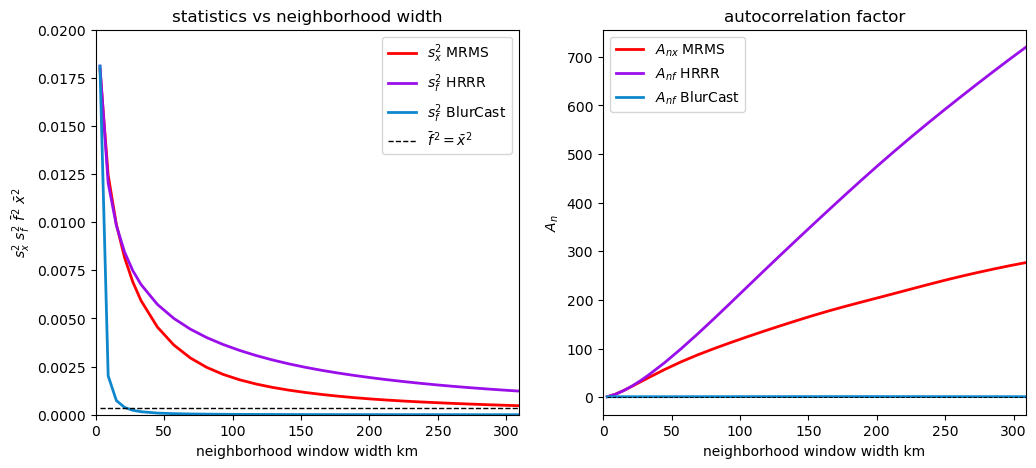

In [6]:
# compare the stats

fig,ax = plt.subplots(1,2,figsize=(12,5))
axs=ax.flat

axs[0].plot(win_width_km,sx_2_n,c=colorlist[0],lw=2.,label=r'$s_x^2$ MRMS')
axs[0].plot(win_width_km,sf_2_skill,c=colorlist[1],lw=2.,label=r'$s_f^2$ HRRR')
axs[0].plot(win_width_km,sf_2_rand,c=colorlist[2],lw=2.,label=r'$s_f^2$ BlurCast')
axs[0].plot(win_width_km,xbar_n*xbar_n,c='k',lw=1.,ls='--',label=r'${\bar f}^2 = {\bar x}^2$')

axs[0].legend(loc='upper right')
axs[0].set_xlabel('neighborhood window width km')
axs[0].set_ylabel(r'$s_x^2$ $s_f^2$ ${\bar f}^2$ ${\bar x}^2$')
axs[0].set_title(r'statistics vs neighborhood width')
axs[0].set_xlim(0.,np.max(win_width_km))
axs[0].set_ylim(0.0,0.02)

# calculate autocorrelation factors following Antonio and Aitchison 2025
s_x_2_0=np.var(obs)
s_f_2_0_skill=np.var(skill_fcst)
s_f_2_0_rand=np.var(rand_fcst)
a_n_obs=sx_2_n*win_size/s_x_2_0
a_n_skill=sf_2_skill*win_size/s_f_2_0_skill
a_n_rand=sf_2_rand*win_size/s_f_2_0_rand

axs[1].plot(win_width_km,a_n_obs,c=colorlist[0],lw=2.,label=r'${A_{nx}}$ MRMS')
axs[1].plot(win_width_km,a_n_skill,c=colorlist[1],lw=2.,label=r'${A_{nf}}$ HRRR')
axs[1].plot(win_width_km,a_n_rand,c=colorlist[2],lw=2.,label=r'${A_{nf}}$ BlurCast')
axs[1].plot(win_width_km,np.zeros_like(win_width),c='k',ls='--',lw=0.7)
axs[1].legend()
axs[1].set_xlabel('neighborhood window width km')
axs[1].set_ylabel(r'$A_n$')
axs[1].set_title(r'autocorrelation factor')
axs[1].set_xlim(0.,np.max(win_width_km))

### multi-scale variability of fields
By analyzing the sample variances of the fractions across increasing neighborhood averaging windows, information regarding the differences in the multi-scale structure of the forecast and observed fields can be obtained. The variances of the forecast and observed fractions decrease monotonically as the neighborhood window size increases. Analyzing the rate at which the variance of the field decreases with increasing averaging scale is a form of "moment-scale" analysis, which Harris et al. (2001) noted provides information about the degree of "intermittency" in a field. A highly intermittent field will have localized peaks which will diminish drastically in amplitude as they are averaged across larger neighborhood windows. For more contiguous/less intermittent fields, blocks of high values are spread across multiple grid boxes, so the neighborhood averaging will diminish the variance at a reduced rate as the window size increases. Comparing these scale-dependent statistics of the forecasts compared to the observations can provide insight into the relative degree of "realism" in the forecast fields.

In the HRRR forecast example above (purple), the variance of the forecast fractions decreases with neighborhood size at a reduced rate compared to the MRMS observations. In this case, the forecast field has higher autocorrelation/lower intermittency than the observed. Larger regions of nearly contiguous "blocks" of binary forecasts maintain higher values of the fractions when compared to the more intermittent observed fractions as the neighborhood averaging process continues, so we should expect the variance of those forecast fractions to remain larger than the observed variance as the neighborhood sizes increase (normalized sharpness > 1). The means of the forecast and observed fractions remain constant with increasing neighborhood size, as expected for a "reflective" convolution operator.

For the BlurCast forecast example (blue), the variance of the highly intermittent forecast field decreases with neighborhood size at a steeper rate compared to the observed field. In this case, the highly intermittent field shows a rapid reduction in variance as the neighborhood averaging scale increases. For the random forecast, the forecast/observation covariance is nearly zero across all neighborhood scales.


### Scale-dependent behavior of the FSS components

In order to understand the behavior of $FSS$, we need to understand the behavior of each of its components, particularly how these can vary with increasing neighborhood window scale. The correlation coefficient $(r)$ will remain bounded between -1 and 1 across all neighborhoods.  While we anticipate that $r$ for skillful forecasts will increase as neighborhoods get larger, that will not necessarily be the case. The fractions means are assumed to remain constant with neighborhood window size, although in practice this will depend on the method used to calculate the fractions near the edges of the spatial domain (here we follow the approach recommended by Antonio and Aitchison (2025) and use a reflective convolution method to maintain constant means). Therefore, we expect that all of the terms involving the fraction means $(\phi_{bias}, \mu^2)$ will remain constant as the neighborhood window size increases. In the synthetic data example above, both of the forecasts are unbiased, resulting in $\phi_{bias}=1$.

The variances of the fractions fields decrease as the neighborhood averaging window increases in size and the fractions become more spatially uniform across the domain. The variances will have their largest value at the grid scale where the forecasts and observations are binary, potentially vanishing if the neighborhood window reaches the size of the full domain. The rate of change of variance with increasing averaging scale provides information about the multi-scale structure of the field (e.g., Plotnick et al. 1996; Harris et al. 2001). Antonio and Aitchison (2025) derived an expression to show how the variance of fractions produced by a binary field vary with neighborhood scale, finding this to be equal to the variance of the binary field at the grid scale divided by the number of points within the neighborhood window ($=width^2=N_w^2$ for a square window), multiplied by a factor that increases with increasing spatial autocorrelation ($A_n$ denotes the autocorrelation factor for the n-th neighborhood). Using our notation, we should expect the observed variance to vary with neighborhood size as follows:

\begin{equation}
s_x^2[n]=s_x^2[n=1]\frac{A_{nx}}{N_w^2}=\bar x(1-\bar x)\frac{A_{nx}}{N_w^2}
\end{equation}

where $N_w$ is the neighborhood window width (in units of number of grid points) and $A_{nx}$ is the autocorrelation factor of the observed fractions at the n-th neighborhood. Antonio and Aitchison (2025) showed that the autocorrelation factor is equal to one ($A_{nx}=1$) when there is no autocorrelation in the field and increases with greater autocorrelation. 

The forecast fractions will follow a similar reduction in variance with increasing neighborhood size, with perhaps differing autocorrelation factors for the forecast fields. 

\begin{equation}
s_f^2[n]=s_f^2[n=1]\frac{A_{nf}}{N_w^2}=\bar f(1-\bar f)\frac{A_{nf}}{N_w^2}
\end{equation} 

When the spatial autocorrelation structure of the forecast field differs from the observed, $s_f^2$ will decrease at a different rate than $s_x^2$, resulting in $\phi_{sharp}\lt 1$. The variance of the HRRR forecast is reduced with increasing neighborhood width at a slower rate than the observed field. This is due to larger spatial autocorrelation in the forecast field in comparison to the observed, resulting in larger continguous blocks of relatively high values of fractions as the neighborhood windows get larger, producing larger values of forecast variance. The differences in the forecasted and observed variances in this case results in a reduction in sharpness skill (see plot below) below one, although the value quickly levels off at around $\phi_{sharp}= 0.9$ for neighborhood widths larger than ~200 km. The variance of the random forecast shrinks with increasing neighborhood width at a much sharper rate than the observed field, due to the lack of spatial autocorrelation in that field (see above). The "patchy" structure of the BlurCast field results in more spatially uniform fractions fields as the neighborhood windows grow larger, rapidly reducing the value of forecast variance. The mismatch between the observed and forecasted variance in this case produces lower values of sharpness skill (see below) for the random (BlurCast) forecast in comparison with the HRRR. However, since this term gets multiplied by the correlation coefficient in the $FSS$ formulation, it does not affect the score for the random forecast since the correlation is $\approx 0$ for the BlurCast.  




(0.0, 1.01)

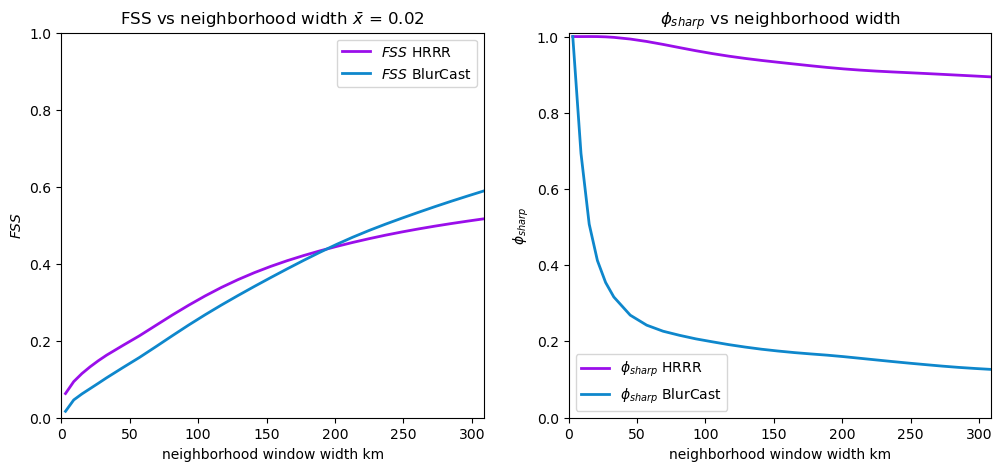

In [7]:
# FSS on the left subplot, sharpness skill phi_sharp on the right subplot
# following Antonio and Aitchison (2025)

phi_bias_skill=2.*fbar_skill*xbar_n/(fbar_skill**2.+xbar_n**2.)
phi_sharp_skill=2.*np.sqrt(sf_2_skill*sx_2_n)/(sf_2_skill+sx_2_n)
phi_bias_rand=2*fbar_rand*xbar_n/(fbar_rand**2.+xbar_n**2.)
phi_sharp_rand=2.*np.sqrt(sf_2_rand*sx_2_n)/(sf_2_rand+sx_2_n)

fig,ax = plt.subplots(1,2,figsize=(12,5))
axs=ax.flat

axs[0].plot(win_width_km,fss_skill,c=colorlist[1],lw=2.,label=r'$FSS$ HRRR')
axs[0].plot(win_width_km,fss_rand,c=colorlist[2],lw=2.,label=r'$FSS$ BlurCast')


axs[0].plot(win_width_km,np.zeros_like(win_width),c='k',ls='--',lw=0.7)
axs[0].legend()
axs[0].set_xlabel('neighborhood window width km')
axs[0].set_ylabel(r'$FSS$')
axs[0].set_title(r'FSS vs neighborhood width $\bar x$ ='+f' {np.round(np.mean(obs),2)}')
axs[0].set_ylim(0.0,1.0)
axs[0].set_xlim(0.,np.max(win_width_km))

axs[1].plot(win_width_km,phi_sharp_skill,c=colorlist[1],lw=2.,label=r'$\phi_{sharp}$ HRRR')
axs[1].plot(win_width_km,phi_sharp_rand,c=colorlist[2],lw=2.,label=r'$\phi_{sharp}$ BlurCast')
axs[1].legend()
axs[1].set_xlabel('neighborhood window width km')
axs[1].set_ylabel(r'$\phi_{sharp}$')
axs[1].set_title(r'$\phi_{sharp}$ vs neighborhood width')
axs[1].set_xlim(0.,np.max(win_width_km))
axs[1].set_ylim(0.0,1.01)



We will shift our focus to the $FSS$ "weight" component $w$, that was discussed previously as potentially having a controlling effect on FSS behavior, since $w$ represents the "baseline" value of $FSS$. $w$ can be considered a measure of the combined uniformity of the fractions fields, therefore we should expect it to increase monotonically as the neighborhood averaging window grows larger in size. We find this to be the case in the synthetic data examples (shown below). To better understand this behavior,  the functions from Antonio and Aitchison (2025) showing how variances decrease with increasing neighborhood width are substituted in the definition of $w$:

\begin {equation}
w=\frac{({\bar f}^2 +{\bar x}^2)N_w^2}{{\bar x}(1-{\bar x})A_{nx}+{\bar f}(1-{\bar f})A_{nf}+({\bar f}^2 +{\bar x}^2)N_w^2}
\end {equation}

which is simplified further when forecasts are unbiased:

\begin {equation}
w[\bar f \approx \bar x]=\frac{\bar x N_w^2}{(1-\bar x)\frac{A_{nx}+A_{nf}}{2}+\bar x N_w^2}
\end {equation}

We find that $w$ is proportional to the neighborhood width, base rate, and mean forecast, and inversely proportional to the degree of spatial autocorrelation in the fractions fields. For unbiased forecasts at the grid scale ($N_w = 1$ and $A_{nx}=A_{nf}=1$ by definition), we find $w=\bar x$, which represents the degree of uniformity (relative proportion of ones) in the binary fields. The rate of increase of $w$ with neighborhood width will be larger for higher base rates as well as lower amounts of autocorrelation in the forecast and/or observed fields. In the synthetic data example, the random forecast has considerably less spatial autocorrelation than the clustered forecast, which results in $w_{random} \gt w_{clustered}$ for all neighbhorhood widths beyond the grid scale (see below). The difference in spatial structure produces a clear advantage for the random forecast in this case, since $w$ establishes the baseline value of $FSS$ and $(1-w)$ provides the weight applied to the correlation coefficient, as the neighborhood widths grow larger, differences in correlation rapidly become less of a factor in the $FSS$ calculation for the random forecast.

Since $w$ is the ratio of the sum of the squared means to the sum of the variances and squared means of the forecasted and observed fractions, competing forecast systems will have a different $w$ values, unless they have matching levels of forecast variance and bias. Forecast systems with reduced spatial autocorrelation (and/or larger $\bar f$) will have an advantage over competing forecast systems. When each forecast has a different "baseline" score, meaningful comparisons of the values of those scores become nearly impossible without complete understanding of the baselines associated with each system. This can be considered similar to comparing measurements of temperature on different interval scales (i.e., $^\circ$C vs $^\circ$F) without full knowledge of the units associated with each measurement. 

The $FSS$ reference recommended by Antonio and Aitchison (2025) increases with neighborhood width quite rapidly. An unbiased, random reference forecast with zero autocorrelation $(A_{nf}=1)$ results in the following:

\begin {equation}
FSS_{random}=w[A_{nf}=1, \bar f =\bar x]=\frac{\bar x N_w^2}{(1-\bar x)\frac{A_{nx}+1}{2}+\bar x N_w^2}
\end {equation}

A forecast system with any amount of spatial autocorrelation will be at a disadvantage in comparison, since $A_{nf}\gt 1$ will produce $w$ that increases with neighborhood width less sharply than the suggested reference $(FSS_{random})$. Forecast with "perfect" multi-scale spatial autocorrelation structure $(A_{nf}=A_{nx})$ may have to display substantial positive correlation in order to be considered "skillful" in comparison with this particular reference. 

### spatial autocorrelation sensitivity of FSS weight term $(w)$

The plot below illustrates the sensitivity of the FSS weight term (reference) to the degree of spatial autocorrelation in the fractions fields. Recall that FSS can be expressed in terms of a weighted sum of the components of skill involving correlation, sharpness, and bias, using the  weight term:

\begin {equation}
w=\frac{{\bar f}^2+{\bar x}^2}{s_f^2+s_x^2+{\bar f}^2+{\bar x}^2}=\frac{{\bar{\mu}}^2}{{\bar{\sigma}}^2+{\bar{\mu}}^2}
\end {equation}

\begin {equation}
FSS=r (1-w) \phi_{sharp} + (w) \phi_{bias}
\end {equation}

$w$ can be considered a "baseline" FSS value, since $FSS\approx w$ for a forecast containing zero correlation with the observations. The complement of this term $(1-w)$ determines the weight applied to the product of the correlation coefficient and the sharpness skill terms in the value of FSS, which is the term most directly related to the degree of similarity between the forecasted and observed fields.

The weight term $w$ is the ratio of the sum of the squared means to the sum of the variances and squared means of the forecasted and observed fractions. In contrast to the other components of FSS, $w$ is not directly related to the degree of difference or similarity between the forecasts and observations, but is instead a measure of the combined "uniformity" of the fractions fields. If the fractions fields are nearly constant, perhaps when the neighborhood window approaches the size of the full domain, the variances will be vanishingly small and the fraction fields are considered completely uniform $(w\approx 1)$. On the other hand, minimum uniformity should be expected at the grid scale when the fields are binary, the variances will have their largest values and $w$ will be small. The weight term $w$ is displayed for the HRRR (purple) and the random BlurCast (blue) across a range of neighborhood windows. Since the BlurCast field has no autocorrelation (same as the FSS reference recommended by Antonio and Aitchison (2025)), the variance of the forecast fractions decreases quite rapidly as the neighborhood width increases, while the variance of the HRRR fractions decreases more gradually. The sum of the forecast and observed variances is in the denominator of $w$, which explains why the BlurCast value of $w$ increases with neighborhood width at a faster rate than the HRRR as the neighborhood windows get larger. Since both of the example forecasts are unbiased, the $\phi_{bias}$ terms are both equal to 1. On the other hand, $w$ for the HRRR is lower than that from the BlurCast, so the HRRR is at an immediate disadvantage to the BlurCast solely due to the HRRR having a higher degree of autocorrelation. The right subplot below shows the amount of "advantage" (or headstart) that the BlurCast has over the HRRR due to the differences in $w$ between the two systems, where $r_{advantage}$ shows the value of the correlation coefficient that a forecast with the same structure (variance) as the HRRR would require to match the $FSS$ value from the BlurCast (which has ~zero correlation with the observed field). While the HRRR correlation exceeds this advantage for smaller neighborhoods, the BlurCast advantage eventually overtakes the HRRR at neighborhood widths of ~200 km in width and larger.

Since the weight term is a function of the forecast mean and variance, it is clear that this baseline for the FSS will vary with every forecast. In addition, the weight term increases monotonically with neighborhood scale, at a rate that depends on the spatial structure of the fields. This is very problematic, unless competing forecasts have identical bias and mulit-scale autocorrelation structure, the forecast system with lower spatial autocorrelation will have an advantage. The information needed to determine the behavior of this baseline/weight is not typically provided in FSS analyses, making post-analysis adjustment of these scores impossible. To use this approach fairly, some modification to the score is needed to ensure that a consistent baseline is applied to all competing forecast systems and all neighborhood widths.

(0.0, 309.0)

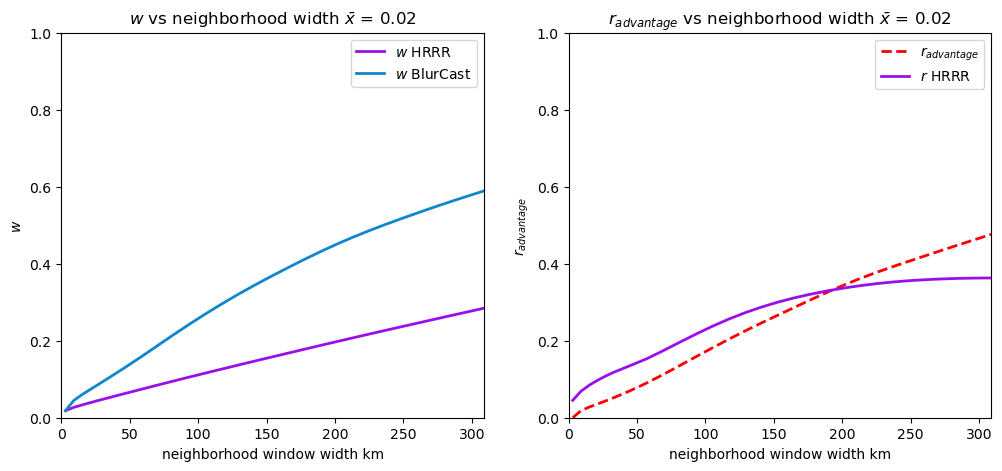

In [8]:
# w on the left subplot, correlation and advantage on the right subplot
# following Antonio and Aitchison (2025)

xbar=np.mean(obs)
b_skill=fbar_skill/xbar_n
b_rand=fbar_rand/xbar_n
s_skill=np.sqrt(sf_2_skill/sx_2_n)
s_rand=np.sqrt(sf_2_rand/sx_2_n)
l_obs=sx_2_n/xbar_n/xbar_n
n_w_k=sx_2_n[0]/sx_2_n
x_odds=xbar/(1.-xbar)
afss_bias_skill=2.*b_skill/(b_skill**2.+1.)
afss_sharp_skill=2.*s_skill/(s_skill**2.+1.)
afss_bias_rand=2.*b_rand/(b_rand**2.+1.)
afss_sharp_rand=2.*s_rand/(s_rand**2.+1.)

w_skill=xbar_n*xbar_n/(sx_2_n*afss_bias_skill*s_skill/afss_sharp_skill/b_skill+xbar_n*xbar_n)
w_rand=xbar_n*xbar_n/(sx_2_n*afss_bias_rand*s_rand/afss_sharp_rand/b_rand+xbar_n*xbar_n)

fig,ax = plt.subplots(1,2,figsize=(12,5))
axs=ax.flat


axs[0].plot(win_width_km,w_skill,c=colorlist[1],lw=2.,label=r'$w$ HRRR')
axs[0].plot(win_width_km,w_rand,c=colorlist[2],lw=2.,label=r'$w$ BlurCast')
axs[0].legend()
axs[0].set_xlabel('neighborhood window width km')
axs[0].set_ylabel(r'$w$')
axs[0].set_title(r'$w$ vs neighborhood width $\bar x$ ='+f' {np.round(xbar,2)}')
axs[0].set_ylim(0.,1.0)
axs[0].set_xlim(0.,np.max(win_width_km))

axs[1].plot(win_width_km,(w_rand-w_skill)/(1.-w_skill)/afss_sharp_skill,c=colorlist[0],ls='--',lw=2.,label=r'$r_{advantage}$')
axs[1].plot(win_width_km,rfx_skill,c=colorlist[1],lw=2.,label=r'$r$ HRRR')
axs[1].legend()
axs[1].set_xlabel('neighborhood window width km')
axs[1].set_ylabel(r'$r_{advantage}$')
axs[1].set_title(r'$r_{advantage}$ vs neighborhood width $\bar x$ ='+f' {np.round(xbar,2)}')
axs[1].set_ylim(0.,1.0)
axs[1].set_xlim(0.,np.max(win_width_km))




## Alternate approaches

$FSS$ has been found to be a weighted combination of three components of MSE-related skill (correlation, sharpness, and bias). The weight term was shown to increase with neighborhood width at a rate that depends upon base rate, bias, and the multi-scale spatial autocorrelation structure of the forecast and observed fields. $w$ is an measure of the combined degree of uniformity in the fractions fields, rather than a measure of the degree of similarity between the uniformity characteristics of the forecast and observed fractions. Since $w$ establishes the "baseline" for $FSS$, the asymptotic behavior of $FSS$ that is typically displayed is driven primarily by the structure of the fields. The fundamental problem with interpretation of $FSS$ lies with the fact that different forecasts will be associated with different weight terms, making meaningful comparisons nearly impossible.

To address these issues with $FSS$ while maintaining a similar combination of the skill components, it is recommended to use a weight term that is consistent across competing forecast systems, so all forecasts use the same "baseline" (similar to converting all temperature measurements to the same units).

### Centered Fractions Skill Score (CFSS)

Rather than using raw values of the forecasts and observations, in this alternate derivation forecast and observed variables will be “centered” by subtracting ther corresponding mean values, similar to how variables are centered in computations of variance and covariance. The centered MSE of the fractions will be the base measure used to derive this alternate skill score. This is identical to calculating the variance of the forecast error, commonly used in the analysis of variance in linear regression. Taylor (2001) derived the geometric relationship between the centered MSE, variances of the observed and forecast fields, and correlation coefficient and showed how these could be combined on a single diagram (known as Taylor diagrams).

\begin{equation}
CFSS=1-\frac{\frac{1}{N}\sum((f_i-\bar f)-(x_i-\bar x))^2}{\frac{1}{N}\sum(f_i-\bar f)^2+\frac{1}{N}\sum(x_i-\bar x)^2}
\end{equation}

\begin{equation}
=\frac{2s_{fx}}{s_f^2+s_x^2}=r \phi_{sharp}
\end{equation}

In this $CFSS$ derivation, centered forecast and observed fields have zero means, which effectively sets the weight term to zero $w=0$. Similar to how $FSS$ can be expressed as a harmonic mean (see appendix), we find that $CFSS$ is the harmonic mean of the forecast/observation covariance, normalized by the variances of the forecasts and observations. $CFSS$ is the product of two of the three MSE-related skill components, which leaves the bias component to be analyzed separately.

### Base-rate Fractions Skill Score (BFSS)

Using a constant weight term equal to the base rate $w=\bar x$ is equivalent to using the value of $w$ at the grid scale for an unbiased orecast, and ensures that all forecasts have a consistent baseline. $BFSS$ may have a behavior that is more consistent with the original intent of Roberts and Lean (2008), where a random forecast will display $BFSS_{random}=\bar x$ across all neighborhood widths, and the criteria for determining a "useful" forecast ($FSS_{uniform}=(1+\bar x)/2$ "i.e., halfway between random forecast skill and perfect skill" Roberts and Lean (2008)) will also be consistent across all neighborhood sizes.

\begin {equation}
BFSS=r (1-\bar x) \phi_{sharp} + (\bar x) \phi_{bias}
\end {equation}

In this $CFSS$ derivation, centered forecast and observed fields have zero means, which effectively sets the weight term to zero $w=0$. Similar to how $FSS$ can be expressed as a harmonic mean (see appendix), we find that $CFSS$ is the harmonic mean of the forecast/observation covariance, normalized by the variances of the forecasts and observations. $CFSS$ is the product of two of the three MSE-related skill components, which leaves the bias component to be analyzed separately.

### Weighted combinations of components

Users can define a score to be consistent with their decision-making needs using a weighted combination of the three MSE-related skill components. They might determine that certain aspects/components of skill should be weighted more heavily than others. This could be a linear combination ("weighted FSS" $WFSS$)

\begin {equation}
WFSS=r (w_{corr}) + \phi_{sharp} (w_{sharp}) + \phi_{bias} (w_{bias})
\end {equation}

or a non-linear combination ("non-linear FSS" $NFSS$) where the components are multiplied, perhaps raising them to different powers to emphasize specific components:

\begin {equation}
NFSS= r^{\alpha}{\phi_{sharp}}^{\beta}{\phi_{bias}}^{\gamma}
\end {equation}

$NFSS$ is similar to the "structural similarity index" $SSIM$ used in the assessment of image quality (Wang and Bovik 2009)

Wang, Z. and Bovik, A.C., 2009. Mean squared error: Love it or leave it? A new look at signal fidelity measures. IEEE signal processing magazine

### Analyze all skill components

All of these summary scores, including $FSS$, reduce information about multiple aspects of forecast quality into a single score, which is typically the case in a "measures-oriented" verification approach (Brooks and Doswell 1996). To obtain more comprehensive information about forecast performance, is it recommended to analyze each component/aspect of quality separately (Murphy 1993; Murphy and Winkler 1987). Using the neighborhood verification approach, valuable information about the multi-scale spatial structure of the forecast and observed fields can be obtained, but this is not typically analyzed. By analyzing the variances of the fractions across increasing neighborhood averaging windows, information regarding the differences in the multi-scale structure of the forecast and observed fields can be obtained. Analyzing the rate at which the variance of the field decreases with increasing averaging scale is a form of "moment-scale" analysis, which Harris et al. (2001) noted provides information about the degree of "intermittency" in a field. A highly intermittent field will have localized peaks which will diminish drastically in amplitude as they are averaged across larger neighborhood windows. For more contiguous/less intermittent fields, blocks of high values are spread across multiple grid boxes, so the neighborhood averaging will diminish the variance at a reduced rate as the window size increases. There may be other spatial/temporal scale-dependent characteristics of the forecasts and observations that can be analyzed to provide insight into the relative degree of "realism" in the forecast fields. 

A recommended approach is to follow Antonio and Aitchison (2025) who displayed the correlation coefficient and the normalized sharpness $(s_f/s_x)$ versus neighborhood width. 

Brooks, H. E., and C. A. Doswell, 1996: A Comparison of Measures-Oriented and Distributions-Oriented Approaches to Forecast Verification. Wea. Forecasting, 11, 288–303

Murphy, A. H., 1993: What is a good forecast? An essay on the nature of goodness in weather forecasting. Wea. Forecasting, 8, 281–293.

Murphy, A. H., and R. L. Winkler, 1987: A General Framework for Forecast Verification. Mon. Wea. Rev., 115, 1330–1338


(-0.05, 0.56)

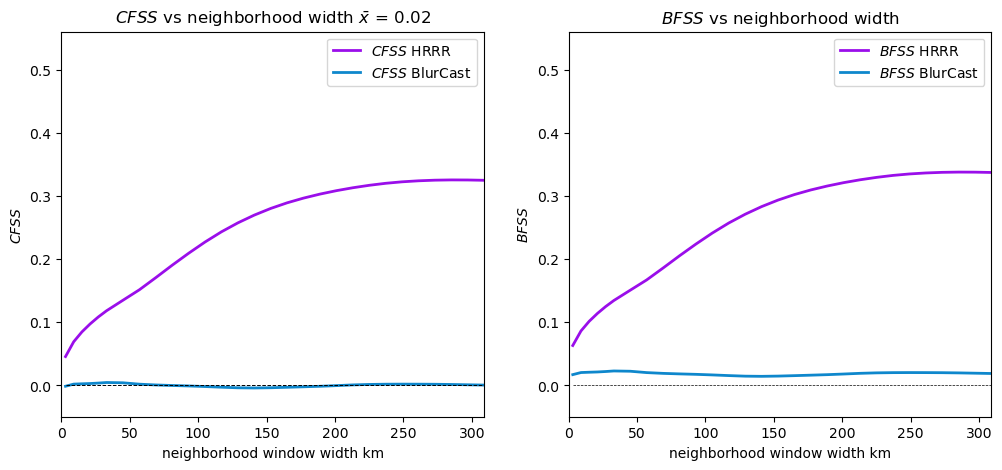

In [9]:
# FSS on the left subplot, correlation and normalized sharpness on the right subplot
# following Antonio and Aitchison (2025)

xbar=np.mean(obs)
b_skill=fbar_skill/xbar_n
b_rand=fbar_rand/xbar_n
s_skill=np.sqrt(sf_2_skill/sx_2_n)
s_rand=np.sqrt(sf_2_rand/sx_2_n)
l_obs=sx_2_n/xbar_n/xbar_n
n_w_k=sx_2_n[0]/sx_2_n
x_odds=xbar/(1.-xbar)
afss_bias_skill=2.*b_skill/(b_skill**2.+1.)
afss_sharp_skill=2.*s_skill/(s_skill**2.+1.)
afss_bias_rand=2.*b_rand/(b_rand**2.+1.)
afss_sharp_rand=2.*s_rand/(s_rand**2.+1.)


w_skill=xbar_n*xbar_n/(sx_2_n*afss_bias_skill*s_skill/afss_sharp_skill/b_skill+xbar_n*xbar_n)
w_rand=xbar_n*xbar_n/(sx_2_n*afss_bias_rand*s_rand/afss_sharp_rand/b_rand+xbar_n*xbar_n)

bfss_skill=rfx_skill*afss_sharp_skill*(1.-w_skill[0])+afss_bias_skill*w_skill[0]
bfss_rand=rfx_rand*afss_sharp_rand*(1.-w_rand[0])+afss_bias_rand*w_rand[0]
cfss_skill=rfx_skill*afss_sharp_skill
cfss_rand=rfx_rand*afss_sharp_rand

fig,ax = plt.subplots(1,2,figsize=(12,5))
axs=ax.flat

axs[0].plot(win_width_km,cfss_skill,c=colorlist[1],lw=2.,label=r'$CFSS$ HRRR')
axs[0].plot(win_width_km,cfss_rand,c=colorlist[2],lw=2.,label=r'$CFSS$ BlurCast')
axs[0].plot(win_width_km,np.zeros_like(win_width),c='k',ls='--',lw=0.7)
axs[0].legend()
axs[0].set_xlabel('neighborhood window width km')
axs[0].set_ylabel(r'$CFSS$')
axs[0].set_title(r'$CFSS$ vs neighborhood width $\bar x$ ='+f' {np.round(xbar,2)}')
axs[0].set_ylim(-0.05,0.56)
axs[0].set_xlim(0.,np.max(win_width_km))

axs[1].plot(win_width_km,bfss_skill,c=colorlist[1],lw=2.,label=r'$BFSS$ HRRR')
axs[1].plot(win_width_km,bfss_rand,c=colorlist[2],lw=2.,label=r'$BFSS$ BlurCast')
axs[1].plot(win_width_km,np.zeros_like(win_width),c='k',ls='--',lw=0.5)
axs[1].legend()
axs[1].set_xlabel('neighborhood window width km')
axs[1].set_ylabel(r'$BFSS$')
axs[1].set_title(r'$BFSS$ vs neighborhood width')
axs[1].set_xlim(0.,np.max(win_width_km))
axs[1].set_ylim(-0.05,0.56)



### Synthetic data example

Synthetic fields can also be used in this notebook. Synthetic observations are generated using a random number generator ("noise") over a 2-D grid, smoothing the noise field with a Gaussian filter to produce spatial autocorrelation, and thresholding using a percentile threshold to generate a binary field with a specific event frequency. A synthetic forecast field is generated by taking a weighted average of the original noise field with a separate random error field, followed by smoothing and thresholding to produce a binary forecast field. The spatial structure of the synthetic fields is controlled by the value of the standard deviation of the Gaussian kernel ("sigma"), larger sigma values will produce more contiguous binary fields with a high degree of spatial autocorrelation ("clustered"), while lower sigma values will generate binary fields that appear more intermittent or noisy. Forecast bias is controlled by the percentile threshold for the forecast field. 

In the results that follow, a square domain of 333x333 points is generated with an event frequency (base rate) of $\bar x=0.1$. ) and sigma = 3 (using the multidimensional Gaussian filter from the scipy.ndimage package in "reflect" mode), which produces a moderate level of autocorrelation in the observed binary field (left panel below). A synthetic “clustered” forecast is generated with an error weight of 0.5 and a higher level of smoothing (sigma = 6; center panel below), choosing a percentile threshold to generate an unbiased forecast ($\bar f=0.1$). At the original grid scale the resulting value of "probability of detection" (POD; Appendix) for the "clustered" forecast is $POD = 0.37$. A “random” forecast is generated by random permutation of the clustered forecast field, resulting in a binary field with no autocorrelation and $POD \approx 0.1$, which is the expected value $(POD=\bar x)$ for an unbiased random forecast.

In [ ]:
# synthetic 2-D observation forecast binary field generator

# colors
colorlist=['xkcd:fire engine red','xkcd:violet','xkcd:water blue','xkcd:medium green']

# seeds for random number generators
obs_rng = np.random.default_rng(10987654321)
fcst_rng = np.random.default_rng(42)
rand_rng = np.random.default_rng(1999)

def make_regions(noise, sigma, prob):
    filtered = gaussian_filter(noise, sigma, mode='reflect')
    threshold = np.quantile(filtered, 1 - prob)
    return (filtered > threshold).astype('float')

def generate_obs_field(size, sigma, prob, rng=obs_rng):
    noise = rng.random(size)    
    return noise, make_regions(noise, sigma, prob)

def generate_forecast_field(truth_noise, sigma, prob, noise_weight, rng=obs_rng):
    noise = rng.random(truth_noise.shape)
    noise = noise_weight * noise + (1 - noise_weight) * truth_noise
    return make_regions(noise, sigma, prob)

# generate obs field with a moderate level of autocorrelation
obs_sigma = 3.

# generate a "skillful/compact" forecast field with a higher level of compactness
skillfcst_sigma=6.
skill_error_weight=0.5

# generate a "random/patchy" forecast field with a lower level of compactness
randfcst_sigma=1.
rand_error_weight=1.0

# specify base rate and bias
base_rate = 0.1
bias=1.

# domain size
ni, nj = 333, 333

# generate fields
obs_noise, obs = generate_obs_field((nj, ni), obs_sigma, base_rate, rng=obs_rng)
skill_fcst = generate_forecast_field(obs_noise, skillfcst_sigma, bias*base_rate, noise_weight=skill_error_weight, rng=fcst_rng)
#rand_fcst = generate_forecast_field(obs_noise, randfcst_sigma, bias*base_rate, noise_weight=rand_error_weight, rng=rand_rng)
rand_fcst=rand_rng.permuted(skill_fcst)

# calculate CSI
skill_csi=np.sum(obs*skill_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*skill_fcst))
rand_csi=np.sum(obs*rand_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*rand_fcst))
skill_pod=np.sum(obs*skill_fcst)/np.sum(obs)
rand_pod=np.sum(obs*rand_fcst)/np.sum(obs)

# plot these fields
fig,ax = plt.subplots(1,3,figsize=(15,6))
axs=ax.flat

cmap_obs=colors.ListedColormap(['white',colorlist[0]])
axs[0].imshow(obs, cmap=cmap_obs, origin='lower')
axs[0].set_title(r'synthetic observed field $\bar x$ = '+f'{base_rate}')

cmap_fcst=colors.ListedColormap(['white',colorlist[1]])
axs[1].imshow(skill_fcst, cmap=cmap_fcst, origin='lower')
axs[1].set_title(r'clustered forecast $CSI$ = '+f'{np.round(skill_csi,2)} $POD$ = '+f'{np.round(skill_pod,2)}')

cmap_rand=colors.ListedColormap(['white',colorlist[2]])
axs[2].imshow(rand_fcst, cmap=cmap_rand, origin='lower')
axs[2].set_title(r'random forecast $CSI$ = '+f'{np.round(rand_csi,2)} $POD$ = '+f'{np.round(rand_pod,2)}')